# NB10 — Evaluación detallada de las 84 corridas

## Propósito

Sobre las predicciones OOF y test ya guardadas en `Outputs/Predicciones_v2/`, calcular para cada combinación (configuración × cabeza):

- **AUC** con IC 95% por bootstrap (1.000 remuestreos)
- **Average Precision** (PR-AUC) con IC 95% — métrica complementaria con desbalance
- **Brier score** — métrica conjunta de discriminación y calibración
- **ECE** (Expected Calibration Error) — calibración pura

Y, sobre los resultados, ejecutar los análisis críticos:

1. **Comparaciones pareadas DeLong** entre configuraciones top (¿GAP+GMP supera a pool 2×2? ¿A+B mejora a A?).
2. **Análisis estratificado por densidad mamaria** (A/B/C/D) sobre el hold-out — cierra una limitación declarada del Hito 2.
3. **Comparación cuantitativa contra Hito 2** (NB05/NB07) con DeLong sobre el mismo test pool.
4. **Análisis post-hoc M→E**: agregar predicciones de mama a estudio con `max(pred_L, pred_R)` y comparar con E_A directo.
5. **Curvas ROC y PR** de las top configuraciones.

## Salida

- `Outputs/Predicciones_v2/eval_completo_v2.csv` — tabla maestra con todas las métricas.
- `Outputs/Predicciones_v2/delong_pareado_v2.csv` — todas las comparaciones DeLong.
- `Outputs/Predicciones_v2/eval_densidad_v2.csv` — AUC por estrato de densidad.
- `Outputs/Predicciones_v2/curvas_top.png` — curvas ROC y PR de las 5 mejores configuraciones.

In [1]:
import os, sys, glob, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, precision_recall_curve

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS      = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR_V2  = os.path.join(OUTPUTS, 'Predicciones_v2')
PRED_DIR_V1  = os.path.join(OUTPUTS, 'Predicciones')      # Hito 2
NB_DIR    = os.path.join(BASE, 'src')

sys.path.insert(0, NB_DIR)
from tfm_eval import (  # noqa: E402
    bootstrap_metric_ci, ece_score, delong_test,
    aggregate_breast_to_study, compute_full_metrics, SEED,
)

np.random.seed(SEED)
print(f'PRED_DIR_V2: {PRED_DIR_V2}')
print(f'PRED_DIR_V1 (Hito 2): {PRED_DIR_V1}')

PRED_DIR_V2: C:\Users\victo\Documents\TFM\Proyecto\Outputs\Predicciones_v2
PRED_DIR_V1 (Hito 2): C:\Users\victo\Documents\TFM\Proyecto\Outputs\Predicciones


## 1. Cargar metadata y etiquetas

Replicamos la misma lógica de construcción de y/splits que en NB09 para garantizar alineación con las predicciones.

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)
print(f'N estudios: {N}')

# Nivel estudio
y_E = meta['y_estudio'].values.astype(int)
split_E = meta['split'].values
is_train_E = (split_E == 'training')
is_test_E  = (split_E == 'test')
density_E  = meta['density'].values
study_ids_E = meta['study_id'].values

# Nivel mama: replicar L y R EN EL MISMO ORDEN que el NB09 construyó
y_M = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
split_M = np.concatenate([meta['split'].values, meta['split'].values])
is_train_M = (split_M == 'training')
is_test_M  = (split_M == 'test')
density_M  = np.concatenate([meta['density_L'].values, meta['density_R'].values])
study_ids_M = np.concatenate([meta['study_id'].values, meta['study_id'].values])

print(f'Nivel estudio: train={is_train_E.sum()} (pos={int(y_E[is_train_E].sum())})  '
      f'test={is_test_E.sum()} (pos={int(y_E[is_test_E].sum())})')
print(f'Nivel mama:    train={is_train_M.sum()} (pos={int(y_M[is_train_M].sum())})  '
      f'test={is_test_M.sum()} (pos={int(y_M[is_test_M].sum())})')

# Para evaluar test:
y_E_test = y_E[is_test_E]
y_M_test = y_M[is_test_M]
density_E_test = density_E[is_test_E]
density_M_test = density_M[is_test_M]
study_ids_E_test = study_ids_E[is_test_E]

# Para OOF, las etiquetas son las del training pool
y_E_oof = y_E[is_train_E]
y_M_oof = y_M[is_train_M]

N estudios: 4999
Nivel estudio: train=3999 (pos=385)  test=1000 (pos=96)
Nivel mama:    train=7998 (pos=395)  test=2000 (pos=99)


## 2. Funciones para cargar predicciones y métricas

Cada corrida está en disco como dos arrays:
- `{config}__{head}_oof.npy` — predicciones OOF sobre el training pool
- `{config}__{head}_test.npy` — predicciones ensemble sobre el test pool

In [3]:
def load_predictions(config, head, source='v2'):
    """Carga (oof, test) para una combinación config-head."""
    pdir = PRED_DIR_V2 if source == 'v2' else PRED_DIR_V1
    oof  = np.load(os.path.join(pdir, f'{config}__{head}_oof.npy'))
    test = np.load(os.path.join(pdir, f'{config}__{head}_test.npy'))
    return oof, test

def get_level(config):
    return 'estudio' if config.startswith('E_') else 'mama'

def get_y_test(config):
    return y_E_test if config.startswith('E_') else y_M_test

def get_y_oof(config):
    return y_E_oof if config.startswith('E_') else y_M_oof

# Listado de todas las corridas v2 (a partir del resumen, no del filesystem para mantener orden)
resumen = pd.read_csv(os.path.join(PRED_DIR_V2, 'resumen_v2.csv'))
runs_v2 = list(zip(resumen['config'], resumen['head']))
print(f'Corridas a evaluar: {len(runs_v2)}')

Corridas a evaluar: 84


## 3. Tabla maestra: métricas completas para las 84 corridas (test)

Para cada corrida calcula AUC + IC95%, AP + IC95%, Brier y ECE sobre el test pool. Bootstrap con n=1000 remuestreos. Tarda aproximadamente 5-10 minutos en total.

In [4]:
rows = []
t0 = time.time()
for i, (config, head) in enumerate(runs_v2, start=1):
    try:
        _, test_pred = load_predictions(config, head)
    except FileNotFoundError as e:
        print(f'  [{i}/{len(runs_v2)}] {config}__{head}  FALTA  ({e})')
        continue
    y_test = get_y_test(config)
    if len(test_pred) != len(y_test):
        print(f'  [{i}/{len(runs_v2)}] {config}__{head}  TAMAÑO INCORRECTO ({len(test_pred)} vs {len(y_test)})')
        continue
    
    metrics = compute_full_metrics(y_test, test_pred, n_boot=1000)
    rows.append({
        'config': config, 'head': head, 'level': get_level(config),
        **metrics,
    })
    if i % 10 == 0:
        print(f'  [{i}/{len(runs_v2)}] {config}__{head}  AUC={metrics["auc"]:.4f}  ({time.time()-t0:.1f}s)')

df_eval = pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)
df_eval.to_csv(os.path.join(PRED_DIR_V2, 'eval_completo_v2.csv'), index=False)
print(f'\nGuardado: eval_completo_v2.csv  ({time.time()-t0:.1f}s)')

  [10/84] M_A_gg__rf  AUC=0.6661  (13.8s)
  [20/84] M_AB_22__rf  AUC=0.6458  (27.1s)
  [30/84] M_AB_22__mlp  AUC=0.6386  (39.8s)
  [40/84] E_A_gg__extratrees  AUC=0.6318  (52.2s)
  [50/84] E_AB_22__histgb  AUC=0.6247  (63.4s)
  [60/84] E_B_gg__xgb  AUC=0.6139  (75.5s)
  [70/84] E_B_22__extratrees  AUC=0.6058  (86.8s)
  [80/84] E_A_22__logreg_l2  AUC=0.5828  (97.8s)

Guardado: eval_completo_v2.csv  (102.3s)


In [5]:
# TOP 15 con todas las métricas
print('TOP 15 por AUC test (con IC 95%, AP, Brier, ECE):')
print()
top = df_eval.head(15)
for _, r in top.iterrows():
    print(f"  {r['config']:14s} {r['head']:12s}  "
          f"AUC={r['auc']:.4f} [{r['auc_lo']:.4f}, {r['auc_hi']:.4f}]   "
          f"AP={r['ap']:.4f}   Brier={r['brier']:.4f}   ECE={r['ece']:.4f}")

TOP 15 por AUC test (con IC 95%, AP, Brier, ECE):

  M_A_gg         mlp           AUC=0.6866 [0.6289, 0.7417]   AP=0.2422   Brier=0.1943   ECE=0.3811
  M_A_22         xgb           AUC=0.6813 [0.6181, 0.7440]   AP=0.3036   Brier=0.1175   ECE=0.2755
  M_AB_gg        histgb        AUC=0.6811 [0.6189, 0.7412]   AP=0.2915   Brier=0.0649   ECE=0.1468
  M_A_22         rf            AUC=0.6803 [0.6210, 0.7374]   AP=0.2847   Brier=0.0407   ECE=0.0107
  M_A_gg         logreg_en     AUC=0.6763 [0.6165, 0.7371]   AP=0.2251   Brier=0.1531   ECE=0.2793
  M_AB_gg        lgbm          AUC=0.6758 [0.6132, 0.7325]   AP=0.2786   Brier=0.0440   ECE=0.0262
  M_A_gg         logreg_l1     AUC=0.6729 [0.6120, 0.7345]   AP=0.2047   Brier=0.1456   ECE=0.2645
  M_AB_gg        mlp           AUC=0.6709 [0.6104, 0.7281]   AP=0.2274   Brier=0.1910   ECE=0.3733
  M_A_gg         histgb        AUC=0.6692 [0.6095, 0.7313]   AP=0.2846   Brier=0.0713   ECE=0.1644
  M_A_gg         rf            AUC=0.6661 [0.6092, 0.7245]

## 4. Comparaciones pareadas con DeLong

Las comparaciones críticas para responder a las preguntas de investigación:

1. **¿Pool 2×2 supera a GAP+GMP?** Para la mejor cabeza, comparamos `{conf}_22` vs `{conf}_gg`.
2. **¿Combinar A+B mejora a A solo?** Comparamos `{M,E}_AB_{p}` vs `{M,E}_A_{p}`.
3. **¿La mejor configuración del NB09 supera a la del Hito 2?**
4. **¿Qué cabeza es mejor en una configuración dada?** (e.g., MLP vs XGB sobre M_A_22)

In [6]:
def delong_two_runs(config_a, head_a, config_b, head_b, source_a='v2', source_b='v2'):
    """DeLong pareado entre dos corridas (test pool).
    Sólo válido si ambas tienen mismo nivel (estudio vs mama)."""
    level_a = get_level(config_a)
    level_b = get_level(config_b)
    if level_a != level_b:
        raise ValueError(f'Niveles distintos: {level_a} vs {level_b}; DeLong inválido')
    _, pred_a = load_predictions(config_a, head_a, source=source_a)
    _, pred_b = load_predictions(config_b, head_b, source=source_b)
    y_test = get_y_test(config_a)
    res = delong_test(y_test, pred_a, pred_b)
    return res

# Comparaciones definidas
comparaciones = []

# (A) Pool 2x2 vs GAP+GMP — para cada (input, level, head) que tenga ambas variantes
for input_type in ['A', 'AB']:
    for level_prefix in ['M', 'E']:
        cfg_gg = f'{level_prefix}_{input_type}_gg'
        cfg_22 = f'{level_prefix}_{input_type}_22'
        # Para cada cabeza presente en ambas
        heads_gg = set(df_eval[df_eval.config == cfg_gg]['head'])
        heads_22 = set(df_eval[df_eval.config == cfg_22]['head'])
        for h in heads_gg & heads_22:
            comparaciones.append(('pool_2x2_vs_gg', cfg_22, h, cfg_gg, h))
# E_B también
for h in set(df_eval[df_eval.config == 'E_B_22']['head']) & set(df_eval[df_eval.config == 'E_B_gg']['head']):
    comparaciones.append(('pool_2x2_vs_gg', 'E_B_22', h, 'E_B_gg', h))

# (B) AB vs A solo — para cada (level, pool, head) común
for level_prefix in ['M', 'E']:
    for pool in ['gg', '22']:
        cfg_A  = f'{level_prefix}_A_{pool}'
        cfg_AB = f'{level_prefix}_AB_{pool}'
        heads_A  = set(df_eval[df_eval.config == cfg_A]['head'])
        heads_AB = set(df_eval[df_eval.config == cfg_AB]['head'])
        for h in heads_A & heads_AB:
            comparaciones.append(('AB_vs_A', cfg_AB, h, cfg_A, h))

print(f'Comparaciones programadas: {len(comparaciones)}')

Comparaciones programadas: 76


In [7]:
delong_rows = []
for tipo, cfg_a, head_a, cfg_b, head_b in comparaciones:
    try:
        res = delong_two_runs(cfg_a, head_a, cfg_b, head_b)
        delong_rows.append({
            'tipo': tipo,
            'config_a': cfg_a, 'head_a': head_a,
            'config_b': cfg_b, 'head_b': head_b,
            'auc_a': res['auc_a'], 'auc_b': res['auc_b'],
            'delta': res['delta'],
            'p_value': res['p_value'],
            'significativo_005': res['p_value'] < 0.05,
        })
    except Exception as e:
        print(f'  Error: {cfg_a}_{head_a} vs {cfg_b}_{head_b}: {e}')

df_delong = pd.DataFrame(delong_rows)
df_delong.to_csv(os.path.join(PRED_DIR_V2, 'delong_pareado_v2.csv'), index=False)
print(f'Total tests DeLong: {len(df_delong)}')
print(f'Significativos (p<0.05): {df_delong.significativo_005.sum()}')

Total tests DeLong: 76
Significativos (p<0.05): 4


In [8]:
# Resumen de DeLong por tipo de comparación
for tipo in df_delong['tipo'].unique():
    sub = df_delong[df_delong['tipo'] == tipo]
    sig = sub[sub['significativo_005']]
    print(f'\n=== {tipo} ===')
    print(f'  Total: {len(sub)}, significativos: {len(sig)} ({100*len(sig)/len(sub):.0f}%)')
    print(f'  Delta medio: {sub["delta"].mean():.4f}  (positivo = primero gana)')
    if len(sig) > 0:
        print(f'  TOP 5 más significativos:')
        for _, r in sig.nsmallest(5, 'p_value').iterrows():
            sign = '+' if r['delta'] > 0 else '-'
            print(f'    {r["config_a"]:14s} {r["head_a"]:12s} vs {r["config_b"]:14s} {r["head_b"]:12s}  '
                  f'Δ={r["delta"]:+.4f}  p={r["p_value"]:.4e}')


=== pool_2x2_vs_gg ===
  Total: 42, significativos: 4 (10%)
  Delta medio: -0.0169  (positivo = primero gana)
  TOP 5 más significativos:
    M_AB_22        lgbm         vs M_AB_gg        lgbm          Δ=-0.0670  p=9.8231e-03
    M_A_22         mlp          vs M_A_gg         mlp           Δ=-0.0445  p=1.4101e-02
    E_AB_22        logreg_l1    vs E_AB_gg        logreg_l1     Δ=-0.0460  p=1.5963e-02
    M_AB_22        mlp          vs M_AB_gg        mlp           Δ=-0.0323  p=2.0734e-02

=== AB_vs_A ===
  Total: 34, significativos: 0 (0%)
  Delta medio: -0.0061  (positivo = primero gana)


## 5. Comparación cuantitativa contra Hito 2

Comparamos las predicciones del NB09 contra las del Hito 2 (M_A_mlp, M_A_gbm, M_A_mlp_dens) sobre el mismo test pool con DeLong.

**Pregunta crítica**: ¿la pipeline unificada del NB09 supera estadísticamente al Hito 2?

In [9]:
# Listar predicciones del Hito 2 disponibles
hito2_runs = []
for p in glob.glob(os.path.join(PRED_DIR_V1, '*_test.npy')):
    name = os.path.basename(p).replace('_test.npy', '')
    hito2_runs.append(name)
print(f'Corridas Hito 2 disponibles: {sorted(hito2_runs)}')

Corridas Hito 2 disponibles: ['E_A_gbm', 'E_A_mlp', 'E_B_gbm', 'E_B_mlp', 'M_A_gbm', 'M_A_gbm_dens', 'M_A_mlp', 'M_A_mlp_dens']


In [10]:
def map_hito2_to_level(name):
    """Heurística para inferir el nivel (estudio/mama) de un run del Hito 2."""
    if name.startswith('M_'): return 'mama'
    if name.startswith('E_'): return 'estudio'
    return None

# Comparar cada run del Hito 2 contra el TOP del NB09 que sea del mismo nivel
best_v2_per_level = {
    'mama':    df_eval[df_eval.level == 'mama'].nlargest(1, 'auc').iloc[0],
    'estudio': df_eval[df_eval.level == 'estudio'].nlargest(1, 'auc').iloc[0],
}
print('TOP NB09 por nivel:')
for lvl, r in best_v2_per_level.items():
    print(f'  {lvl:8s}: {r["config"]}__{r["head"]}  AUC={r["auc"]:.4f}')

hito2_vs_v2 = []
for h2_name in hito2_runs:
    level = map_hito2_to_level(h2_name)
    if level is None: continue
    try:
        h2_test = np.load(os.path.join(PRED_DIR_V1, f'{h2_name}_test.npy'))
    except FileNotFoundError:
        continue
    y_test = get_y_test('M_dummy' if level == 'mama' else 'E_dummy')
    if len(h2_test) != len(y_test):
        print(f'  {h2_name}: shape {len(h2_test)} != esperado {len(y_test)}, salto')
        continue
    # AUC del Hito 2
    h2_auc = roc_auc_score(y_test, h2_test)
    # Best NB09 del mismo nivel
    best = best_v2_per_level[level]
    _, v2_test = load_predictions(best['config'], best['head'])
    res = delong_test(y_test, v2_test, h2_test)
    hito2_vs_v2.append({
        'hito2_run': h2_name, 'hito2_auc': h2_auc,
        'v2_best': f'{best["config"]}__{best["head"]}', 'v2_auc': res['auc_a'],
        'delta_v2_minus_hito2': res['delta'],
        'p_value': res['p_value'],
    })

df_h2_vs_v2 = pd.DataFrame(hito2_vs_v2).sort_values('hito2_auc', ascending=False)
print(df_h2_vs_v2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

TOP NB09 por nivel:
  mama    : M_A_gg__mlp  AUC=0.6866
  estudio : E_A_gg__rf  AUC=0.6499
   hito2_run  hito2_auc     v2_best  v2_auc  delta_v2_minus_hito2  p_value
M_A_mlp_dens     0.7067 M_A_gg__mlp  0.6866               -0.0201   0.3348
     M_A_mlp     0.6830 M_A_gg__mlp  0.6866                0.0037   0.8923
     E_B_gbm     0.6312  E_A_gg__rf  0.6499                0.0187   0.5129
     E_A_mlp     0.6211  E_A_gg__rf  0.6499                0.0288   0.2957
     E_B_mlp     0.6065  E_A_gg__rf  0.6499                0.0435   0.1850
     M_A_gbm     0.6032 M_A_gg__mlp  0.6866                0.0835   0.0028
M_A_gbm_dens     0.6032 M_A_gg__mlp  0.6866                0.0835   0.0028
     E_A_gbm     0.5953  E_A_gg__rf  0.6499                0.0546   0.0185


## 6. Análisis estratificado por densidad mamaria

Cierra una limitación declarada en la memoria del Hito 2 (sección 5.8). Para cada categoría de densidad (A, B, C, D) calculamos AUC sobre el hold-out test, usando la **mejor configuración por nivel**.

In [11]:
def auc_por_estrato(y_true, y_pred, densities, n_boot=1000):
    """Calcula AUC + IC95% por estrato de densidad."""
    rows = []
    for d in ['A', 'B', 'C', 'D']:
        mask = densities == d
        n = int(mask.sum())
        n_pos = int(y_true[mask].sum())
        if n_pos < 5 or (n - n_pos) < 5:
            rows.append({'densidad': d, 'n': n, 'n_pos': n_pos, 'auc': np.nan, 'auc_lo': np.nan, 'auc_hi': np.nan})
            continue
        auc, lo, hi = bootstrap_metric_ci(y_true[mask], y_pred[mask], roc_auc_score, n_boot=n_boot)
        rows.append({'densidad': d, 'n': n, 'n_pos': n_pos, 'auc': auc, 'auc_lo': lo, 'auc_hi': hi})
    return pd.DataFrame(rows)

# Aplicar a las 5 mejores configuraciones por nivel
density_rows = []
top_by_level = {
    'mama':    df_eval[df_eval.level == 'mama'].nlargest(5, 'auc'),
    'estudio': df_eval[df_eval.level == 'estudio'].nlargest(5, 'auc'),
}

for level, top in top_by_level.items():
    densities = density_M_test if level == 'mama' else density_E_test
    y_test = y_M_test if level == 'mama' else y_E_test
    print(f'\n=== {level.upper()} ===')
    for _, r in top.iterrows():
        _, test_pred = load_predictions(r['config'], r['head'])
        df_d = auc_por_estrato(y_test, test_pred, densities)
        df_d.insert(0, 'config', r['config']); df_d.insert(1, 'head', r['head']); df_d.insert(2, 'level', level)
        density_rows.append(df_d)
        print(f'\n  {r["config"]}__{r["head"]}  (AUC global = {r["auc"]:.4f})')
        for _, dr in df_d.iterrows():
            if not np.isnan(dr['auc']):
                print(f'    {dr["densidad"]}: n={dr["n"]:4d}  pos={dr["n_pos"]:3d}  AUC={dr["auc"]:.4f} [{dr["auc_lo"]:.4f}, {dr["auc_hi"]:.4f}]')
            else:
                print(f'    {dr["densidad"]}: n={dr["n"]:4d}  pos={dr["n_pos"]:3d}  AUC=NaN (n_pos insuficiente)')

df_density = pd.concat(density_rows, ignore_index=True)
df_density.to_csv(os.path.join(PRED_DIR_V2, 'eval_densidad_v2.csv'), index=False)
print(f'\nGuardado: eval_densidad_v2.csv')


=== MAMA ===

  M_A_gg__mlp  (AUC global = 0.6866)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.6298 [0.3884, 0.8446]
    C: n=1530  pos= 82  AUC=0.6926 [0.6355, 0.7511]
    D: n= 270  pos=  6  AUC=0.7071 [0.5357, 0.9123]

  M_A_22__xgb  (AUC global = 0.6813)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.6795 [0.4397, 0.8908]
    C: n=1530  pos= 82  AUC=0.6693 [0.6029, 0.7335]
    D: n= 270  pos=  6  AUC=0.7273 [0.4606, 0.9351]

  M_AB_gg__histgb  (AUC global = 0.6811)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.6470 [0.4284, 0.8522]
    C: n=1530  pos= 82  AUC=0.6701 [0.6023, 0.7344]
    D: n= 270  pos=  6  AUC=0.7797 [0.5786, 0.9460]

  M_A_22__rf  (AUC global = 0.6803)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.7445 [0.5710, 0.9004]
    C: n=1530  pos= 82  AUC=0.6518 [0.5846, 0.7141]
    D: n= 270  pos=  6  AUC=0.8472 [0.7682, 0.9

## 7. Análisis post-hoc: agregar M→E

Para cada modelo a nivel mama, calculamos su predicción agregada a nivel estudio tomando `max(pred_L, pred_R)`. Comparamos con el mismo modelo entrenado directamente a nivel estudio.

**Pregunta**: ¿es mejor predecir por mama y agregar al estudio, o predecir directamente a nivel estudio?

In [12]:
post_hoc_rows = []
for _, r in df_eval[df_eval.level == 'mama'].iterrows():
    cfg_m, head, auc_m = r['config'], r['head'], r['auc']
    # Cargar predicciones a nivel mama (test)
    _, pred_m_test = load_predictions(cfg_m, head)
    # Agregar a estudio con max
    pred_e_agg, _ = aggregate_breast_to_study(pred_m_test, study_ids_E_test, agg='max')
    auc_e_agg = roc_auc_score(y_E_test, pred_e_agg)
    
    # Comparar con E_A_{pool}_{head} (configuración análoga a nivel estudio)
    parts = cfg_m.split('_')
    pool = parts[-1]
    inp  = parts[1]    # A o AB
    cfg_e_direct = f'E_{inp}_{pool}'
    direct_row = df_eval[(df_eval['config'] == cfg_e_direct) & (df_eval['head'] == head)]
    if len(direct_row) == 0:
        auc_e_direct = np.nan; pval = np.nan
    else:
        _, pred_e_direct = load_predictions(cfg_e_direct, head)
        auc_e_direct = roc_auc_score(y_E_test, pred_e_direct)
        res = delong_test(y_E_test, pred_e_agg, pred_e_direct)
        pval = res['p_value']
    
    post_hoc_rows.append({
        'config_mama': cfg_m, 'head': head,
        'auc_mama': auc_m,
        'auc_estudio_agg_max': auc_e_agg,
        'config_estudio_directo': cfg_e_direct,
        'auc_estudio_directo': auc_e_direct,
        'delta_agg_minus_directo': auc_e_agg - auc_e_direct if not np.isnan(auc_e_direct) else np.nan,
        'p_delong': pval,
    })

df_post_hoc = pd.DataFrame(post_hoc_rows).sort_values('auc_estudio_agg_max', ascending=False)
df_post_hoc.to_csv(os.path.join(PRED_DIR_V2, 'post_hoc_mama_to_estudio.csv'), index=False)
print('Top 10 — Mama agregada vs Estudio directo:')
print(df_post_hoc.head(10).to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x))

Top 10 — Mama agregada vs Estudio directo:
config_mama      head  auc_mama  auc_estudio_agg_max config_estudio_directo  auc_estudio_directo  delta_agg_minus_directo  p_delong
     M_A_22       xgb    0.6813               0.6891                 E_A_22               0.6315                   0.0576    0.0552
    M_AB_gg      lgbm    0.6758               0.6721                E_AB_gg               0.6283                   0.0438    0.1553
     M_A_22        rf    0.6803               0.6679                 E_A_22               0.6374                   0.0305    0.1208
    M_AB_gg    histgb    0.6811               0.6628                E_AB_gg               0.6393                   0.0235    0.3385
     M_A_22    histgb    0.6653               0.6571                 E_A_22               0.6347                   0.0224    0.4823
     M_A_gg       mlp    0.6866               0.6553                 E_A_gg               0.6237                   0.0315    0.1742
     M_A_22      lgbm    0.6415  

## 8. Curvas ROC y PR — top 5 configuraciones

Visualización comparativa de las mejores configuraciones por nivel.

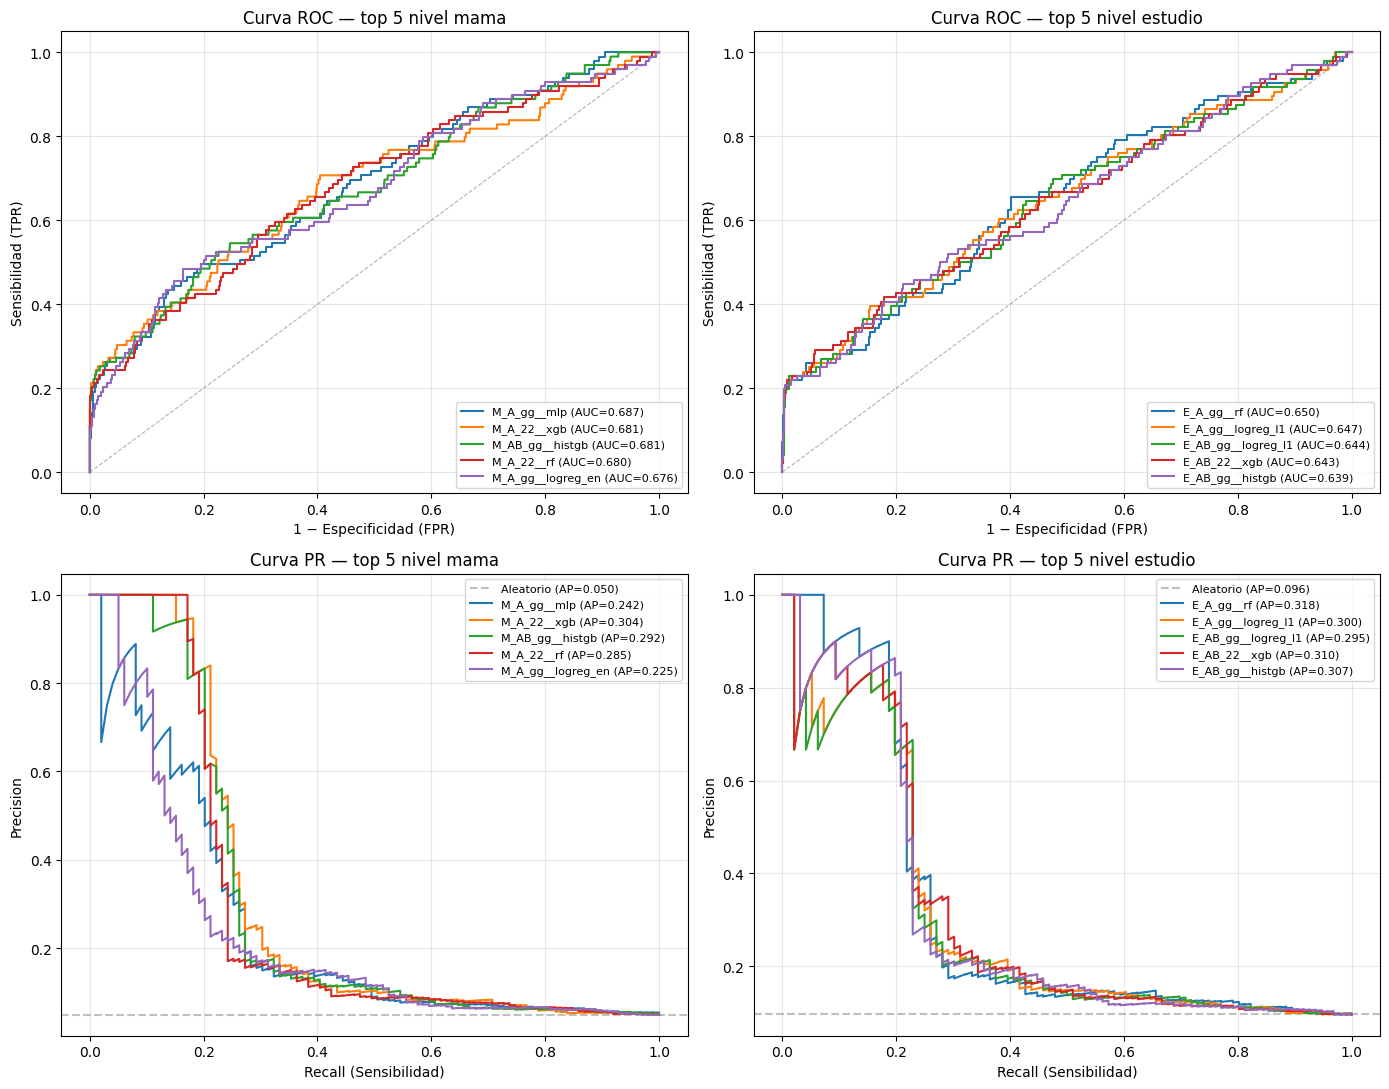

Guardado: curvas_top.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for col, level in enumerate(['mama', 'estudio']):
    top5 = df_eval[df_eval.level == level].nlargest(5, 'auc')
    y_test = y_M_test if level == 'mama' else y_E_test
    
    # ROC
    ax = axes[0, col]
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
    for _, r in top5.iterrows():
        _, pred = load_predictions(r['config'], r['head'])
        fpr, tpr, _ = roc_curve(y_test, pred)
        ax.plot(fpr, tpr, label=f'{r["config"]}__{r["head"]} (AUC={r["auc"]:.3f})', linewidth=1.5)
    ax.set_xlabel('1 − Especificidad (FPR)')
    ax.set_ylabel('Sensibilidad (TPR)')
    ax.set_title(f'Curva ROC — top 5 nivel {level}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    
    # PR
    ax = axes[1, col]
    prevalencia = y_test.mean()
    ax.axhline(prevalencia, color='gray', linestyle='--', alpha=0.5, label=f'Aleatorio (AP={prevalencia:.3f})')
    for _, r in top5.iterrows():
        _, pred = load_predictions(r['config'], r['head'])
        prec, rec, _ = precision_recall_curve(y_test, pred)
        ax.plot(rec, prec, label=f'{r["config"]}__{r["head"]} (AP={r["ap"]:.3f})', linewidth=1.5)
    ax.set_xlabel('Recall (Sensibilidad)')
    ax.set_ylabel('Precision')
    ax.set_title(f'Curva PR — top 5 nivel {level}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'curvas_top.png'), dpi=140, bbox_inches='tight')
plt.show()
print(f'Guardado: curvas_top.png')

## 9. Resumen ejecutivo final

Esta celda imprime un resumen consolidado para usarlo directamente en la redacción del capítulo 5 de la memoria.

In [14]:
print('═' * 75)
print(' RESUMEN EJECUTIVO — NB10 evaluación')
print('═' * 75)

print('\n1. MEJORES CONFIGURACIONES (test AUC + IC95%)')
for level in ['mama', 'estudio']:
    top3 = df_eval[df_eval.level == level].nlargest(3, 'auc')
    print(f'\n  Nivel {level}:')
    for _, r in top3.iterrows():
        print(f'    {r["config"]:14s} {r["head"]:12s}  '
              f'AUC={r["auc"]:.4f} [{r["auc_lo"]:.4f}, {r["auc_hi"]:.4f}]   '
              f'AP={r["ap"]:.4f}   Brier={r["brier"]:.4f}   ECE={r["ece"]:.4f}')

print('\n2. HALLAZGOS METODOLÓGICOS (DeLong)')
for tipo in df_delong['tipo'].unique():
    sub = df_delong[df_delong['tipo'] == tipo]
    sig = sub[sub['significativo_005']]
    delta_mean = sub['delta'].mean()
    sign = 'primero gana' if delta_mean > 0 else 'segundo gana'
    print(f'  {tipo:20s}: {len(sig)}/{len(sub)} significativos  Δ medio = {delta_mean:+.4f} ({sign} en promedio)')

print('\n3. COMPARACIÓN CONTRA HITO 2')
if len(df_h2_vs_v2) > 0:
    for _, r in df_h2_vs_v2.iterrows():
        sig = '★' if r['p_value'] < 0.05 else ' '
        print(f'  {sig}  {r["v2_best"]:25s} vs {r["hito2_run"]:20s}  '
              f'Δ={r["delta_v2_minus_hito2"]:+.4f}  p={r["p_value"]:.4f}')
else:
    print('  (no se pudieron cargar predicciones del Hito 2)')

print('\n4. CALIBRACIÓN DEL TOP NIVEL MAMA')
best_mama = df_eval[df_eval.level == 'mama'].nlargest(1, 'auc').iloc[0]
print(f'   {best_mama["config"]}__{best_mama["head"]}: Brier={best_mama["brier"]:.4f}  ECE={best_mama["ece"]:.4f}')
print('   (Si Brier > 0.15 o ECE > 0.1, el NB12 de calibración Platt/isotónica mejorará estos números)')

print('\n' + '═' * 75)
print(' Archivos generados:')
print('═' * 75)
for f in ['eval_completo_v2.csv', 'delong_pareado_v2.csv', 'eval_densidad_v2.csv',
         'post_hoc_mama_to_estudio.csv', 'curvas_top.png']:
    path = os.path.join(PRED_DIR_V2, f)
    exists = '✓' if os.path.isfile(path) else '✗'
    print(f'  {exists}  {f}')

═══════════════════════════════════════════════════════════════════════════
 RESUMEN EJECUTIVO — NB10 evaluación
═══════════════════════════════════════════════════════════════════════════

1. MEJORES CONFIGURACIONES (test AUC + IC95%)

  Nivel mama:
    M_A_gg         mlp           AUC=0.6866 [0.6289, 0.7417]   AP=0.2422   Brier=0.1943   ECE=0.3811
    M_A_22         xgb           AUC=0.6813 [0.6181, 0.7440]   AP=0.3036   Brier=0.1175   ECE=0.2755
    M_AB_gg        histgb        AUC=0.6811 [0.6189, 0.7412]   AP=0.2915   Brier=0.0649   ECE=0.1468

  Nivel estudio:
    E_A_gg         rf            AUC=0.6499 [0.5879, 0.7119]   AP=0.3178   Brier=0.0753   ECE=0.0206
    E_A_gg         logreg_l1     AUC=0.6465 [0.5759, 0.7111]   AP=0.3002   Brier=0.2163   ECE=0.3560
    E_AB_gg        logreg_l1     AUC=0.6437 [0.5750, 0.7059]   AP=0.2950   Brier=0.2228   ECE=0.3667

2. HALLAZGOS METODOLÓGICOS (DeLong)
  pool_2x2_vs_gg      : 4/42 significativos  Δ medio = -0.0169 (segundo gana en promedio

## Siguientes pasos

- **NB11 — Fusión con densidad** sobre la mejor configuración (`M_A_gg + mlp` según los resultados actuales). Replica el experimento del NB07 del Hito 2 pero sobre la mejor combinación encontrada en el NB09, bajo el mismo protocolo unificado.
- **NB12 — Calibración post-hoc** (Platt e isotónica) sobre el mejor MLP a nivel mama. Reduce Brier y ECE sin tocar AUC.
- Tras NB11 y NB12, el experimental está completo y se procede a la **redacción definitiva** de los capítulos 4 (Metodología), 5 (Resultados) y 6 (Conclusiones) de la memoria.